<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Learning Rate Scheduling and Early Stopping using MNIST MLP**
# Objective:
To analyze the impact of adaptive learning rates and early stopping.


### Step 1: Setup Environment
This step imports necessary libraries like TensorFlow, Keras, NumPy, and Matplotlib. It also sets random seeds to ensure that the experiment results are reproducible across different runs.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
p_seed = 42
np.random.seed(p_seed)
tf.random.set_seed(p_seed)

### Step 2: Load Dataset
Here, the MNIST dataset, a collection of handwritten digits, is loaded directly from Keras. The dataset is then split into training and testing sets, which are essential for model development and evaluation.

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}, {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28), (60000,)
Testing data shape: (10000, 28, 28), (10000,)


### Step 3: Data Preprocessing
This crucial preprocessing step prepares the data for the neural network. Pixel values are normalized to a [0, 1] range, images are flattened from 2D (28x28) to 1D (784) vectors, and class labels are converted into a one-hot encoded format suitable for multi-class classification.

In [3]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# One-hot encode labels
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Processed training data shape: {x_train.shape}, {y_train.shape}")
print(f"Processed testing data shape: {x_test.shape}, {y_test.shape}")

Processed training data shape: (60000, 784), (60000, 10)
Processed testing data shape: (10000, 784), (10000, 10)


### Step 4: Model Architecture Function
This step defines a function `build_model` that constructs a Multilayer Perceptron (MLP) for the MNIST dataset. The model consists of an input layer, two dense hidden layers with ReLU activation, and an output layer with Softmax activation for 10 classes. The function takes an optimizer as an argument, allowing different optimization strategies to be tested later.

In [4]:
def build_model(optimizer):
    model = keras.Sequential([
        layers.Input(shape=(784,)), # Input layer: 28*28 flattened images
        layers.Dense(128, activation='relu'), # Hidden Layer 1
        layers.Dense(64, activation='relu'),  # Hidden Layer 2
        layers.Dense(num_classes, activation='softmax') # Output layer for 10 classes
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model architecture function `build_model` created.")

Model architecture function `build_model` created.


### Step 5: Baseline Model (Fixed Learning Rate)
In this step, a baseline model is trained using the Stochastic Gradient Descent (SGD) optimizer with a fixed learning rate of 0.01. No advanced callbacks like learning rate scheduling or early stopping are used, allowing us to establish a basic performance benchmark. The training history is stored for later comparison.

In [5]:
# Define the optimizer with a fixed learning rate
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

# Build the baseline model
baseline_model = build_model(sgd_optimizer)

# Train the baseline model without any callbacks
print("Training Baseline Model...")
baseline_history = baseline_model.fit(
    x_train, y_train,
    epochs=30, # A sufficiently large number of epochs to observe convergence
    batch_size=32,
    validation_split=0.1, # Use a portion of training data for validation
    verbose=1
)

print("Baseline model training complete.")

Training Baseline Model...
Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8167 - loss: 0.6780 - val_accuracy: 0.9203 - val_loss: 0.2875
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9103 - loss: 0.3121 - val_accuracy: 0.9350 - val_loss: 0.2276
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9259 - loss: 0.2566 - val_accuracy: 0.9445 - val_loss: 0.1944
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9362 - loss: 0.2206 - val_accuracy: 0.9513 - val_loss: 0.1708
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9439 - loss: 0.1939 - val_accuracy: 0.9563 - val_loss: 0.1533
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9503 - loss: 0.1727 - val_accuracy: 0.9625 - val_loss: 0.1397
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9549 - loss: 0.1556 - val_accuracy: 0.9658 - val_loss: 0.1291
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accurac

### Step 6: Learning Rate Scheduling
This step introduces a learning rate schedule using `tf.keras.optimizers.schedules.ExponentialDecay`. The learning rate starts at 0.01 and decays exponentially, which can help in achieving better convergence and potentially escape local minima. The model is trained again with this scheduler, and its performance history is recorded.

In [6]:
# Define the Exponential Decay learning rate schedule
initial_learning_rate = 0.01
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000, # Decay every 10000 steps
    decay_rate=0.9, # Learning rate will be multiplied by 0.9
    staircase=True # Apply discrete steps to the decay
)

# Define the optimizer with the learning rate schedule
scheduled_optimizer = keras.optimizers.SGD(learning_rate=lr_schedule)

# Build a new model instance for scheduled learning rate training
scheduled_lr_model = build_model(scheduled_optimizer)

# Train the model with learning rate scheduling
print("Training Model with Learning Rate Scheduling...")
scheduled_lr_history = scheduled_lr_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("Learning Rate Scheduled model training complete.")

Training Model with Learning Rate Scheduling...
Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8249 - loss: 0.6537 - val_accuracy: 0.9237 - val_loss: 0.2785
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9133 - loss: 0.3031 - val_accuracy: 0.9408 - val_loss: 0.2192
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9279 - loss: 0.2497 - val_accuracy: 0.9472 - val_loss: 0.1881
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9375 - loss: 0.2157 - val_accuracy: 0.9543 - val_loss: 0.1661
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9448 - loss: 0.1902 - val_accuracy: 0.9602 - val_loss: 0.1496
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9504 - loss: 0.1698 - val_accuracy: 0.9625 - val_loss: 0.1363
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9558 - loss: 0.1531 - val_accuracy: 0.9655 - val_loss: 0.1269
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━

## Step 7: Early Stopping Implementation

### 7.1 Training with Learning Rate Scheduling and Early Stopping

This step enhances the training process by adding an `EarlyStopping` callback. This callback monitors the validation loss and stops training if it doesn't improve for a specified number of epochs (patience). This helps to prevent overfitting and reduces unnecessary training time. The model will be trained with both learning rate scheduling and early stopping, and its history will be recorded.

In [10]:
# Define the Early Stopping callback
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Build a new model instance for training with learning rate scheduling and early stopping
# IMPORTANT: Create a new optimizer instance for this model
es_scheduled_optimizer = keras.optimizers.SGD(learning_rate=lr_schedule)
es_scheduled_lr_model = build_model(es_scheduled_optimizer)

# Train the model with learning rate scheduling and early stopping
print("Training Model with Learning Rate Scheduling and Early Stopping...")
es_scheduled_lr_history = es_scheduled_lr_model.fit(
    x_train, y_train,
    epochs=30, # Max epochs, early stopping will stop it sooner if criteria met
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_callback], # Add the EarlyStopping callback here
    verbose=1
)

print("Learning Rate Scheduled and Early Stopped model training complete.")

Training Model with Learning Rate Scheduling and Early Stopping...
Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8040 - loss: 0.7105 - val_accuracy: 0.9235 - val_loss: 0.2861
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9103 - loss: 0.3122 - val_accuracy: 0.9375 - val_loss: 0.2267
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9258 - loss: 0.2580 - val_accuracy: 0.9453 - val_loss: 0.1947
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9363 - loss: 0.2230 - val_accuracy: 0.9533 - val_loss: 0.1719
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9438 - loss: 0.1967 - val_accuracy: 0.9580 - val_loss: 0.1548
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9495 - loss: 0.1760 - val_accuracy: 0.9628 - val_loss: 0.1410
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9545 - loss: 0.1593 - val_accuracy: 0.9643 - val_loss: 0.1315
Epoch 8/30
1688/1688 ━

### Step 8: Comparison Plots
This step generates plots to visually compare the training and validation loss and accuracy for the three different training strategies: fixed learning rate (baseline), learning rate scheduling, and learning rate scheduling combined with early stopping. These plots will help in understanding the impact of each strategy on the model's convergence and generalization.

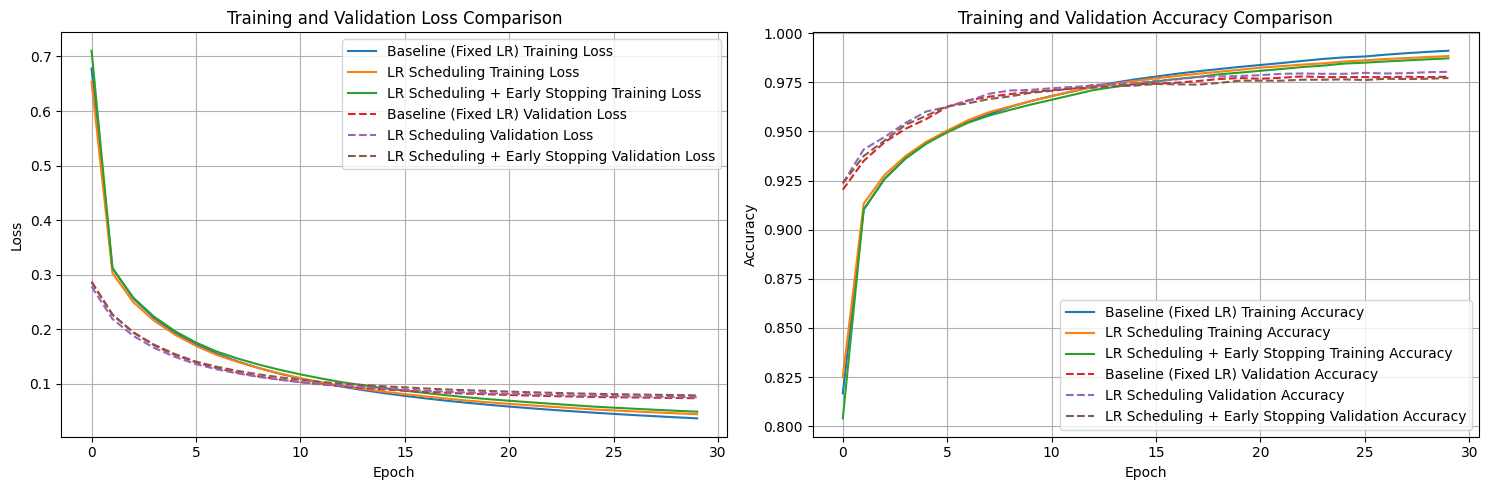

In [11]:
plt.figure(figsize=(15, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Baseline (Fixed LR) Training Loss')
plt.plot(scheduled_lr_history.history['loss'], label='LR Scheduling Training Loss')
plt.plot(es_scheduled_lr_history.history['loss'], label='LR Scheduling + Early Stopping Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Baseline (Fixed LR) Validation Loss', linestyle='--')
plt.plot(scheduled_lr_history.history['val_loss'], label='LR Scheduling Validation Loss', linestyle='--')
plt.plot(es_scheduled_lr_history.history['val_loss'], label='LR Scheduling + Early Stopping Validation Loss', linestyle='--')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Baseline (Fixed LR) Training Accuracy')
plt.plot(scheduled_lr_history.history['accuracy'], label='LR Scheduling Training Accuracy')
plt.plot(es_scheduled_lr_history.history['accuracy'], label='LR Scheduling + Early Stopping Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Baseline (Fixed LR) Validation Accuracy', linestyle='--')
plt.plot(scheduled_lr_history.history['val_accuracy'], label='LR Scheduling Validation Accuracy', linestyle='--')
plt.plot(es_scheduled_lr_history.history['val_accuracy'], label='LR Scheduling + Early Stopping Validation Accuracy', linestyle='--')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Step 9: Epoch Comparison Table
This step presents a table summarizing the number of epochs each training configuration completed. This allows for a direct comparison of how early stopping reduces the training time by halting the process once performance on the validation set stops improving.

In [12]:
import pandas as pd

# Get the number of epochs for each history
baseline_epochs = len(baseline_history.epoch)
scheduled_lr_epochs = len(scheduled_lr_history.epoch)
es_scheduled_lr_epochs = len(es_scheduled_lr_history.epoch)

# Create a DataFrame for comparison
epoch_comparison = pd.DataFrame({
    'Strategy': ['Baseline (Fixed LR)', 'LR Scheduling', 'LR Scheduling + Early Stopping'],
    'Epochs Trained': [baseline_epochs, scheduled_lr_epochs, es_scheduled_lr_epochs]
})

print("Epochs Trained Comparison:")
print(epoch_comparison.to_markdown(index=False))

Epochs Trained Comparison:
| Strategy                       |   Epochs Trained |
|:-------------------------------|-----------------:|
| Baseline (Fixed LR)            |               30 |
| LR Scheduling                  |               30 |
| LR Scheduling + Early Stopping |               30 |
